# Level 3 — Score + Aggregate with Coiled

Uses two Coiled clusters sequentially:
- **crs-score** (e2-standard-8, 25-60 workers) — scoring phase, fully shut down after
- **crs-agg** (e2-highmem-16, 5-30 workers) — aggregation phase, stays warm for reuse

In [1]:
import sys
sys.path.insert(0, "/home/stefan/CRS/CRS.ZarrPipelines/")
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import Client
from app.utils.compute import get_or_create_cluster
from app.domain.pipeline import score_hazard, aggregate_hazard
from app.domain.special.rf import cleanup_tmp
cleanup_tmp()

/home/stefan/CRS/CRS.ZarrPipelines/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Step 1 — Scoring (crs-score cluster)

Reads input zarr from GCS, applies all scoring scales, writes `HS.zarr` to GCS.

In [2]:
score_cluster = get_or_create_cluster(cluster_type="score")
score_client = Client(score_cluster)
print(f"Score cluster ready — dashboard: {score_client.dashboard_link}")

Output()

2026-03-10 11:03:08,727 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=25 maximum=60


Score cluster ready — dashboard: https://cluster-dlirc.dask.host/OSzR4xOQBg2I6e6v/status


2026-03-10 11:07:03,728 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=25 maximum=60. Reason: cluster-not-running


In [4]:
score_hazard("CF", scales=["5", "10", "100"])
print("Scoring complete")

Found config at: /home/stefan/CRS/CRS.ZarrPipelines/app/config/scoring.yaml
Scoring complete


In [ ]:
score_hazard("WF", scales=["5", "10", "100"])
print("Scoring complete")

In [ ]:
# Fully shut down score cluster before moving to aggregation (stops billing)
score_cluster.close()  # shutdown_on_close=True in pipeline.yaml ensures full teardown
score_client.close()
print("Score cluster shut down")

## Inspect scored zarr

In [2]:
ds = xr.open_zarr("gs://crs_climate_data_public/production_test/hazard_scores/RF.zarr")
print(ds)
print("scoring dim:", ds.scoring.values)
for coord in ("scenario", "time", "statistic", "model"):
    if coord in ds.coords:
        print(f"{coord}: {ds[coord].values}")

<xarray.Dataset> Size: 45GB
Dimensions:    (scoring: 3, scenario: 2, time: 4, statistic: 1, lat: 21600,
                lon: 43200)
Coordinates:
  * scoring    (scoring) <U3 36B '5' '10' '100'
  * scenario   (scenario) <U5 40B 'RCP45' 'RCP85'
  * time       (time) <U2 32B 'Cc' 'St' 'Mt' 'Lt'
  * statistic  (statistic) <U4 16B 'mean'
  * lat        (lat) float32 86kB 90.0 89.99 89.98 89.97 ... -89.98 -89.99 -90.0
  * lon        (lon) float32 173kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Data variables:
    score      (scoring, scenario, time, statistic, lat, lon) float16 45GB dask.array<chunksize=(1, 1, 1, 1, 1000, 1000), meta=np.ndarray>
scoring dim: ['5' '10' '100']
scenario: ['RCP45' 'RCP85']
time: ['Cc' 'St' 'Mt' 'Lt']
statistic: ['mean']


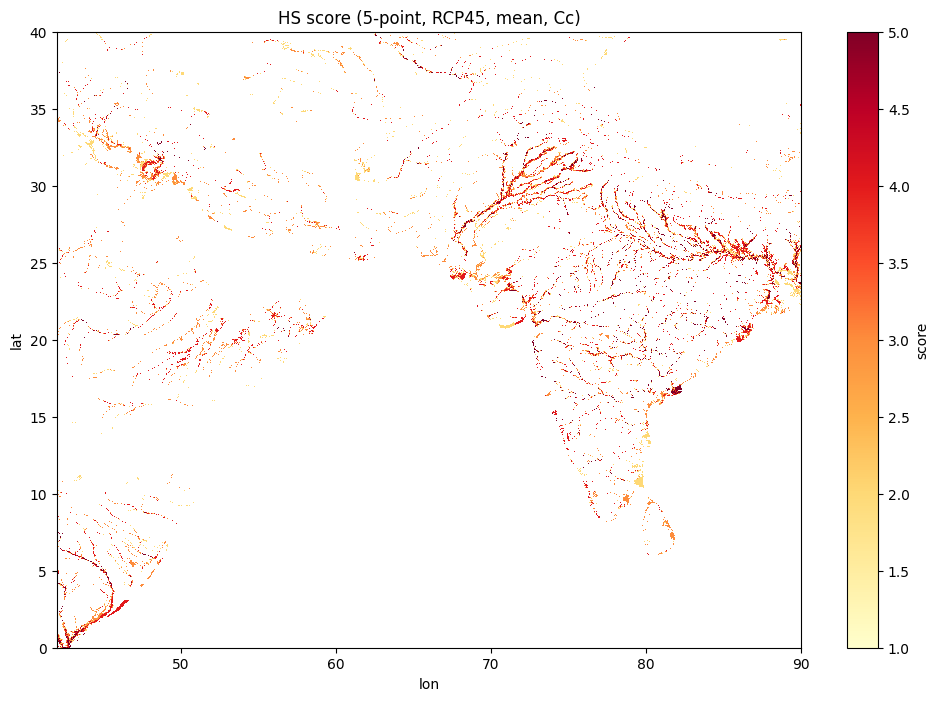

In [3]:
# Set figure size (width, height) in inches
plt.figure(figsize=(12, 8))

sel = dict(scoring="5", scenario="RCP45", time="St", statistic='mean',
           lat=slice(40,0), lon=slice(42, 90))
ds.sel(**sel)["score"].compute().plot(cmap="YlOrRd", vmin=1, vmax=5)
plt.title("HS score (5-point, RCP45, mean, Cc)")
plt.show()

## Step 2 — Aggregation (crs-agg cluster)

Loads scored zarr by country, runs xvec zonal stats, writes per-hazard CSV to GCS.

In [4]:
agg_cluster = get_or_create_cluster(cluster_type="agg")
agg_client = Client(agg_cluster)
print(f"Agg cluster ready — dashboard: {agg_client.dashboard_link}")

Output()

KeyboardInterrupt: 

In [ ]:
aggregate_hazard("RF", gadm_levels=[0,1])
print("Aggregation complete")

In [10]:
aggregate_hazard("LS", gadm_levels=[0,1])
print("Aggregation complete")


KeyboardInterrupt



In [ ]:
# Agg cluster stays warm (shutdown_on_close=False) — just close the client
agg_client.close()
print("Agg client closed (cluster stays warm for reuse)")

## Check CSV output

In [ ]:
fn = "gs://crs_climate_data_public/production_test/aggregations/LS_adm1.csv"
df = pd.read_csv(fn, storage_options={"token": "google_default"})
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Scoring scales: {sorted(df['scoring'].unique())}")
df.head()

## Plot score_mean distributions — all three scales

In [ ]:
scales = sorted(df["scoring"].unique())
n = len(scales)
subset = df[(df["statistic"] == "mean") & (df["scenario"] == "RCP45") & (df["time"] == "Cc")]

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, scale in zip(axes, scales):
    group = subset[subset["scoring"] == scale]
    group["score_mean"].dropna().hist(ax=ax, bins=20, edgecolor="white")
    label = f"{scale}-point" if str(scale) != "100" else "0-100 min-max"
    ax.set_title(f"HS — {label}")
    ax.set_xlabel("score_mean")
    ax.set_ylabel("province count")

plt.suptitle("HS score_mean per province (global, RCP45, mean, Cc)")
plt.tight_layout()
plt.show()